### Setup

In [2]:
import torch
import matplotlib.pyplot as plt

In [3]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Gradients

In [4]:
x = torch.tensor(5.0, requires_grad=True)
x

tensor(5., requires_grad=True)

In [5]:
f = x **2
f

tensor(25., grad_fn=<PowBackward0>)

In [6]:
f.backward()
x.grad

tensor(10.)

In [7]:
g = x**3
g.backward()
x.grad # Wrong, should be 75, not 85.

tensor(85.)

In [8]:
x = torch.tensor(5.0, requires_grad=True)
f = x **2
g = x**3
f.backward()
df = x.grad
x.grad = None
g.backward()
dg = x.grad
x.grad = None
print(df, dg)

tensor(10.) tensor(75.)


In [9]:
x = torch.tensor(5.0, requires_grad=True)
f = x **2
f.backward()
learning_rate = 0.1
with torch.no_grad(): # Dont calculate Gradient for this block of operation
    x-= learning_rate * x.grad
x

tensor(4., requires_grad=True)

In [10]:
with torch.no_grad(): # Dont calculate Gradient for this block of operation
    x-= learning_rate * x.grad
x

tensor(3., requires_grad=True)

In [11]:
x = torch.tensor(5.0, requires_grad=True)
x_detached = x.detach()
f = x **2
f.backward()
learning_rate = 0.1
with torch.no_grad(): # Dont calculate Gradient for this block of operation
    x_detached-= learning_rate * x.grad
x_detached

tensor(4.)

In [12]:
with torch.no_grad(): # Dont calculate Gradient for this block of operation
    x_detached-= learning_rate * x.grad
x_detached

tensor(3.)

In [13]:
x.grad.zero_()

tensor(0.)

In [14]:
x = torch.tensor(5.0, requires_grad=True)
f = x **2
g = x**3
f.backward()
df = x.grad
print(df)
x.grad.zero_()
g.backward()
dg = x.grad
print(dg)
x.grad.zero_()

tensor(10.)
tensor(75.)


tensor(0.)

In [15]:
learning_rate = 0.1
epochs = 30
x_grads = []
x_pos = []
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(epochs):
    f = x ** 2 # forward pass
    f.backward() # backward pass
    with torch.no_grad():
        x_grads.append(x.grad.item())
        x-= learning_rate * x.grad # gradient descent step
        x_pos.append(x.item())
    x.grad.zero_() # reset the gradients
x

tensor(0.0062, requires_grad=True)

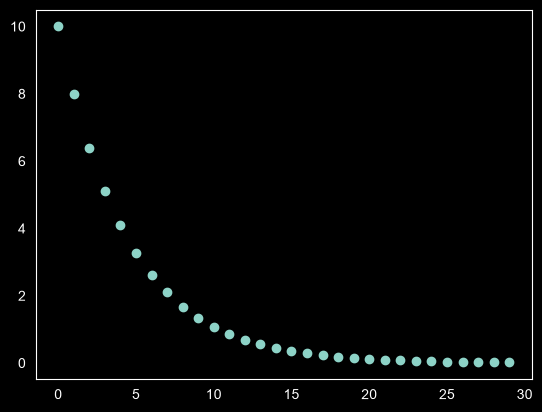

In [28]:
plt.scatter(list(range(epochs)), x_grads)
plt.grid()
plt.show()

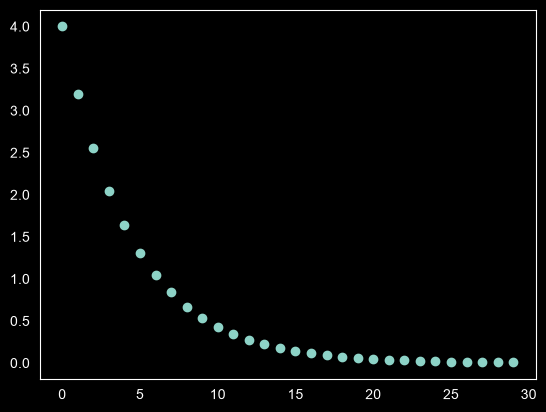

In [34]:
plt.scatter(list(range(epochs)), x_pos)
plt.grid()
plt.show()